## Need this here

In [1]:
import numpy as np

In [2]:
from typing import List, NamedTuple
Edge = NamedTuple('Edge', [('v', int), ('w', int)]) # edge contains two indices to coordinates-array

In [3]:
def compute_partitions(coordinates: np.ndarray, partitions: int) -> List[np.ndarray]:
    """
    Partitions the coordinates into an array of indices. For this matter we use the angles
    between the reference vector of the x-axis.

    :param coordinates: a 2D real array of x- and y-coordinates
    :param partitions: number of partitions
    :return: list of arrays that contain indices of heliostats with regards to the coordinates array
    """
    if partitions > len(coordinates) - 1: # not enough heliostats
        return []

    degrees = np.degrees(np.arctan2(coordinates[1:,1], coordinates[1:,0]))
    indices = degrees.argsort()
    padding = (-len(indices))%partitions
    L = np.split(np.concatenate((indices,np.ones(padding)*-1)),partitions) # padding value: -1
    # remove padding from last partition and increase index
    return [np.delete(a, np.where(a == -1)) + 1 for a in L]


In [4]:
class EdgeSolution:
    def __init__(self, partitions: int) -> None:
        """
        :param partitions: number of edge partitions
        """
        self.edges= [[] for _ in range(partitions)] # type: List[List[Edge]]
        self.edges_coords = [np.empty((0,4)) for _ in range(partitions)]
        self.edge_costs = {} # type: Dict[Edge,int]

    def add_edge(self, edge: Edge, edge_cost: float, partition: int, coordinates: np.ndarray):
        self.edges[partition].append(edge)
        self.edge_costs[edge] = edge_cost

        edges_coords = np.array([[coordinates[edge.v][0], coordinates[edge.v][1],
                                 coordinates[edge.w][0], coordinates[edge.w][1]]])
        self.edges_coords[partition] = np.vstack((self.edges_coords[partition], edges_coords))

    def remove_edge(self, edge: Edge, partition: int, coordinates: np.ndarray):
        self.edges.remove(edge)
        del self.edge_costs[edge]

        edges_coords = np.array([[coordinates[edge.v][0], coordinates[edge.v][1],
                                 coordinates[edge.w][0], coordinates[edge.w][1]]])
        delete_index = np.where(np.all(edges_coords == self.edges_coords[partition], axis=1))
        self.edges_coords[partition] = np.delete(self.edges_coords[partition], delete_index, axis=0)

    def intersects(self, edges_coords: np.ndarray) -> bool:
        """
        Checks whether a given edge that is represented by its coordinates is intersecting
        with our solution edges.

        :param edges_coords: a numpy array that holds both x- and y-coordinates
        :returns: True if edges_coords intersects with solution edges
        """
        return is_edge_intersecting(edges_coords, self.edges_coords)

    def cost(self, distances: np.ndarray):
        return sum(distances[e.v,e.w]*self.edge_costs[e] for e in chain.from_iterable(self.edges))

In [5]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_solution_data(coordinates: np.ndarray,
                       output: str,
                       edges: List[List[Edge]],
                       value: float,
                       edge_cost: float,
                       partitions: int) -> None:
    plt.figure(figsize=(16,16), dpi=350)
    plt.axis('equal')

    coordinates_arr = np.array([tuple(x) for x in coordinates])
    for i,all_edges in enumerate(edges):
        edges_arr = np.array([tuple(list(x)) for x in all_edges])

        x = coordinates_arr[:,0].flatten()
        y = coordinates_arr[:,1].flatten()

        norm = matplotlib.colors.Normalize(vmin=0, vmax=len(edges), clip=True)
        mapper = cm.ScalarMappable(norm=norm, cmap=cm.cool)

        plt.plot(x[edges_arr.T], y[edges_arr.T], linestyle='-', color=mapper.to_rgba(i),
                 markerfacecolor='red', marker='o')
    plt.title("Cable cost/m: {}€ \nPartitions: {}\nTotal costs: {:0,.2f}€".format(edge_cost, partitions, value))
    plt.scatter(coordinates_arr[:,0], coordinates_arr[:,1], color='red', marker='o')
    plt.savefig(output, dpi=300)
    plt.close()


## NEW SOLUTION CLASS

In [6]:
from typing import Generator

class PowerCableSolution(EdgeSolution):
    def __init__(self, n: int, partitions: int):
        """
        :param n: number of vertices
        :param partitions: number of partitions
        """
        super().__init__(partitions)
        self.predecessor = {} # type: Dict[int,int]
        self.successors = {i:[] for i in range(n)} # type: Dict[int,List[int]]
        self.number_children_heliosats = {i:0 for i in range(n)} # type: Dict[int,int]
        self.heliostat_parents = {i:[] for i in range(n)} # type: Dict[int,List[int]]

    def add_edge(self, edge: Edge, edge_cost: float, partition: int, coordinates: np.ndarray):
        super().add_edge(edge, edge_cost, partition, coordinates)
        if not self.predecessor[edge.w]:
            self.predecessor[edge.w] = edge.v
        else:
            raise ValueError('{} has already a predecessor connection to {}'.format(edge.v, self.predecessors[edge.v]))
        self.successors[edge.v].append(edge.w)
        
        for parent in self.heliostat_parents(edge.w):
            self.number_children_heliosats[parent] += 1

    def remove_edge(self, edge: Edge, partition: int, coordinates: np.ndarray):
        super().remove_edge(edge, partition, coordinates)
        del self.predecessor[edge.w]
        self.successors[edge.v].remove(edge.w)
        
        for parent in self.heliostat_parents(edge.w):
            self.number_children_heliosats[parent] -= 1

    def cost(self, distances: np.ndarray):
        return super().cost(distances)
    
    def heliostat_parents(self, vertex: int) -> Generator[int,None,None]:
        """
        Generator that computes the parent vertices up to the
        solar tower.
        
        :param vertex: starting vertex from where we start obtaining predecessor vertices
        """
        pred = vertex
        while pred in self.predecessor:
            yield self.predecessor[pred]
            pred = self.predecessor[pred]

## NEW ALGORITHM CLASS

In [7]:
from typing import List
from recordclass import RecordClass
from scipy.spatial.distance import cdist

MCMSTState = RecordClass('MCMSTState', [('unvisited', List[int])])
Candidate = RecordClass('Candidate', [('vertex', int),
                                      ('edge_cost', float),
                                      ('edges_add', List[Edge]),
                                      ('edges_remove', List[Edge])])

class MCMST:
    # __slots__ = ('coordinates', 'edge_costs', 'partitions', 'solution', 'current_state')
    
    def __init__(self, coordinates: np.ndarray, cable_costs: List[float], partitions: int, work_cost: float, open_trenches: List[List[Edge]]):
        """
        todoc
        !assume cable_costs is sorted in ascending order!
        """
        self.coordinates = coordinates
        self.cable_costs = cable_costs
        self.partitions = partitions
        self.solution = PowerCableSolution(self.coordinates.shape[0], partitions)
        
        self.distances = cdist(coordinates,coordinates)
        indices = np.vstack(open_trenches)
        self.trench_cost = np.self.distances[indices[:,0], indices[:,1]]*trench_cost
        
    def compute(self) -> None:
        for i, p in enumerate(compute_partitions(coordinates=self.coordinates, partitions=self.partitions)):
            self.current_state = MCMSTState(unvisited=p)
            self._mcmst(i, p)
            
    def _mcmst(self, partition, partition_indices) -> None:
        """
        """
        for i,_ in enumerate(reversed(self.cable_costs)):
            for candidate in self.next_candidate(partition_indices, i):
                self._upgrade_vertex(partition, candidate)
                
    def next_candidate(self, partition_indices: np.ndarray, i: int) -> Generator[Candidate,None,None]:
        """
        :param partition_indices:
        :param i: index to self.cable_costs
        """
        for self.current_state.unvisited:
            pass # TODO
            
    
    def _upgrade_vertex(self, partition: int, candidate: Candidate) -> None:
        for r in candidate.edges_remove:
            self.solution.remove_edge(r, i, self.coordinates)
        for a in candidate.edges_add:
            self.solution.add_edge(a, i, candidate.edge_cost, self.coordinates)

SyntaxError: invalid syntax (<ipython-input-7-c1919c1bd006>, line 45)

## PERFORM

In [26]:
coordinates = np.loadtxt('../data/instances/PS10.csv', delimiter=';')
coordinates = np.vstack((np.array([0,0]), coordinates))

In [27]:
PowerCables = NamedTuple('PowerCables', [('max_heliostats', int),
                                         ('max_length', float),
                                         ('price', float)])

In [ ]:
MCMST(coordinates, [])

In [ ]:
q = cdist(coordinates, coordinates)
plot_solution_data(coordinates, '/home/duc/a.png', mcmst.solution.edges, mcmst.solution.cost(q), -1, 3)

## PLAYGROUND

In [507]:
coords = coordinates[:3].copy()

In [508]:
import matplotlib.pyplot as plt

In [509]:
%matplotlib inline

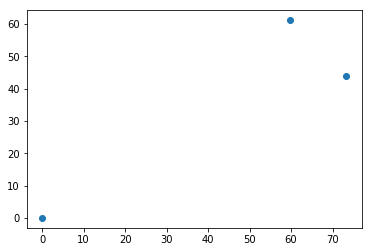

In [510]:
plt.scatter(coords[:,0], coords[:,1])
plt.show()

In [511]:
coords

array([[ 0.  ,  0.  ],
       [73.33, 43.86],
       [59.72, 61.12]])

In [61]:
cable_cost = np.array([0.58,0.87,1.24,1.95,3.13,5.19,6.9])
cable_length = np.array([38.36,47.08,56.04,69.3,84.87,102.79,120.31])
cable_capacity = np.array([56,73,92,124,162,209,250])

In [66]:
from scipy.spatial.distance import cdist

In [534]:
# init stuff

## capacities
current_cap = np.ones(coords.shape[0])
current_cap[0] = coords.shape[0] - 1

current_max_cap = np.ones(coords.shape[0]) * np.min(cable_capacity)

# cable length
current_max_cable_length = np.ones(coords.shape[0]) * np.min(cable_length)

## cost to parent
current_cable_cost = np.ones(coords.shape[0]) * np.min(cable_cost) * cdist(coords,coords)[0,np.arange(coords.shape[0])]
current_cable_cost[0] = 0

## 
parents = {i:[0] for i in range(coords.shape[0])}
pred = np.zeros(coords.shape[0], dtype=int)

# distances
distance = cdist(coords, coords)

In [535]:
current_cable_cost

array([ 0.        , 49.55857677, 49.56246033])

In [539]:
def upgrade_cost(vertex: np.ndarray, cable_index: int):
    i = vertex
    cost = distance[pred[i],i]*current_cable_cost[i] - distance[pred[i],i]*cable_cost[cable_index]
    
    # mask away upgrades that 
    if distance[pred[i],i] > cable_length[cable_index]:
        return np.inf
    else:
        return cost

In [540]:
def reconnecting_profit(candidates: np.ndarray, new_parent: int):
    j = candidates
    profit = distance[pred[j],j]*current_cable_cost[j] - distance[new_parent,j]*current_cable_cost[j]
    return profit

In [541]:
def max_number_reconnections(new_parent: int) -> int:
    indices = parents[new_parent]
    return np.min(current_max_cap[indices] - current_cap[indices])

In [542]:
def candidate_indices(new_parent: int):
    """
    :param new_parent: new parent for candidates
    """
    candidates = np.arange(coords.shape[0])
    
    # capacity constraint
    mask_capacity = current_cap[candidates] < max_number_reconnections(new_parent)
    mask_capacity[0] = False
    mask_capacity[new_parent] = False
    
    # cable length constraint
    mask_cable_length = distance[new_parent,candidates] < current_max_cable_length[candidates]
    
    return candidates[np.logical_and(mask_capacity, mask_cable_length)]

In [543]:
vec_candidate_indices = np.vectorize(candidate_indices)

In [544]:
def best_candidates(new_parent: int, cable_index: int):
    candidates = candidate_indices(new_parent)
    profit = reconnecting_profit(candidates, new_parent) - upgrade_cost(new_parent, cable_index)
    print(reconnecting_profit(candidates, new_parent))
    print(upgrade_cost(new_parent, cable_index))
    return candidates[profit > 0]
    return (-profit).argsort()

In [545]:
from itertools import product

In [546]:
best_candidates(1,5)

[3145.83238649]
3791.109513736654


array([], dtype=int64)

In [551]:
best_candidates(1,4)

[3145.83238649]
inf


array([], dtype=int64)

In [554]:
for i,j in product(range(1,3), range(7)):
    print("a:{}".format(best_candidates(i,j)))

[3145.83238649]
inf
a:[]
[3145.83238649]
inf
a:[]
[3145.83238649]
inf
a:[]
[3145.83238649]
inf
a:[]
[3145.83238649]
inf
a:[]
[3145.83238649]
3791.109513736654
a:[]
[3145.83238649]
3644.9971580891934
a:[]
[3145.25405485]
inf
a:[]
[3145.25405485]
inf
a:[]
[3145.25405485]
inf
a:[]
[3145.25405485]
inf
a:[]
[3145.25405485]
inf
a:[]
[3145.25405485]
3791.738456568175
a:[]
[3145.25405485]
3645.6146511137595
a:[]


In [521]:
best_candidates(1,4)

array([], dtype=int64)